# NYC TLC Yellow Taxi (2024-01) — EDA
Following `docs/eda_checklist.md`.

Note: no rider/driver identifier in this data (anonymized). Rec-context section (#10) reframed as pickup-zone -> dropoff-zone demand (PULocationID -> DOLocationID) instead of user-item.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_PATH = "../../data/raw/ride/nyc_tlc/2024-01/yellow_tripdata_2024-01.parquet"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
trips = pd.read_parquet(DATA_PATH)
print(trips.shape)
trips.head()

(2964624, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


In [3]:
trips.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
dtype: object

## 2. Missing Values

In [4]:
(trips.isna().mean() * 100).round(2).sort_values(ascending=False)

store_and_fwd_flag       4.73
RatecodeID               4.73
passenger_count          4.73
Airport_fee              4.73
congestion_surcharge     4.73
VendorID                 0.00
tpep_pickup_datetime     0.00
tpep_dropoff_datetime    0.00
DOLocationID             0.00
PULocationID             0.00
trip_distance            0.00
fare_amount              0.00
payment_type             0.00
extra                    0.00
mta_tax                  0.00
tolls_amount             0.00
tip_amount               0.00
total_amount             0.00
improvement_surcharge    0.00
dtype: float64

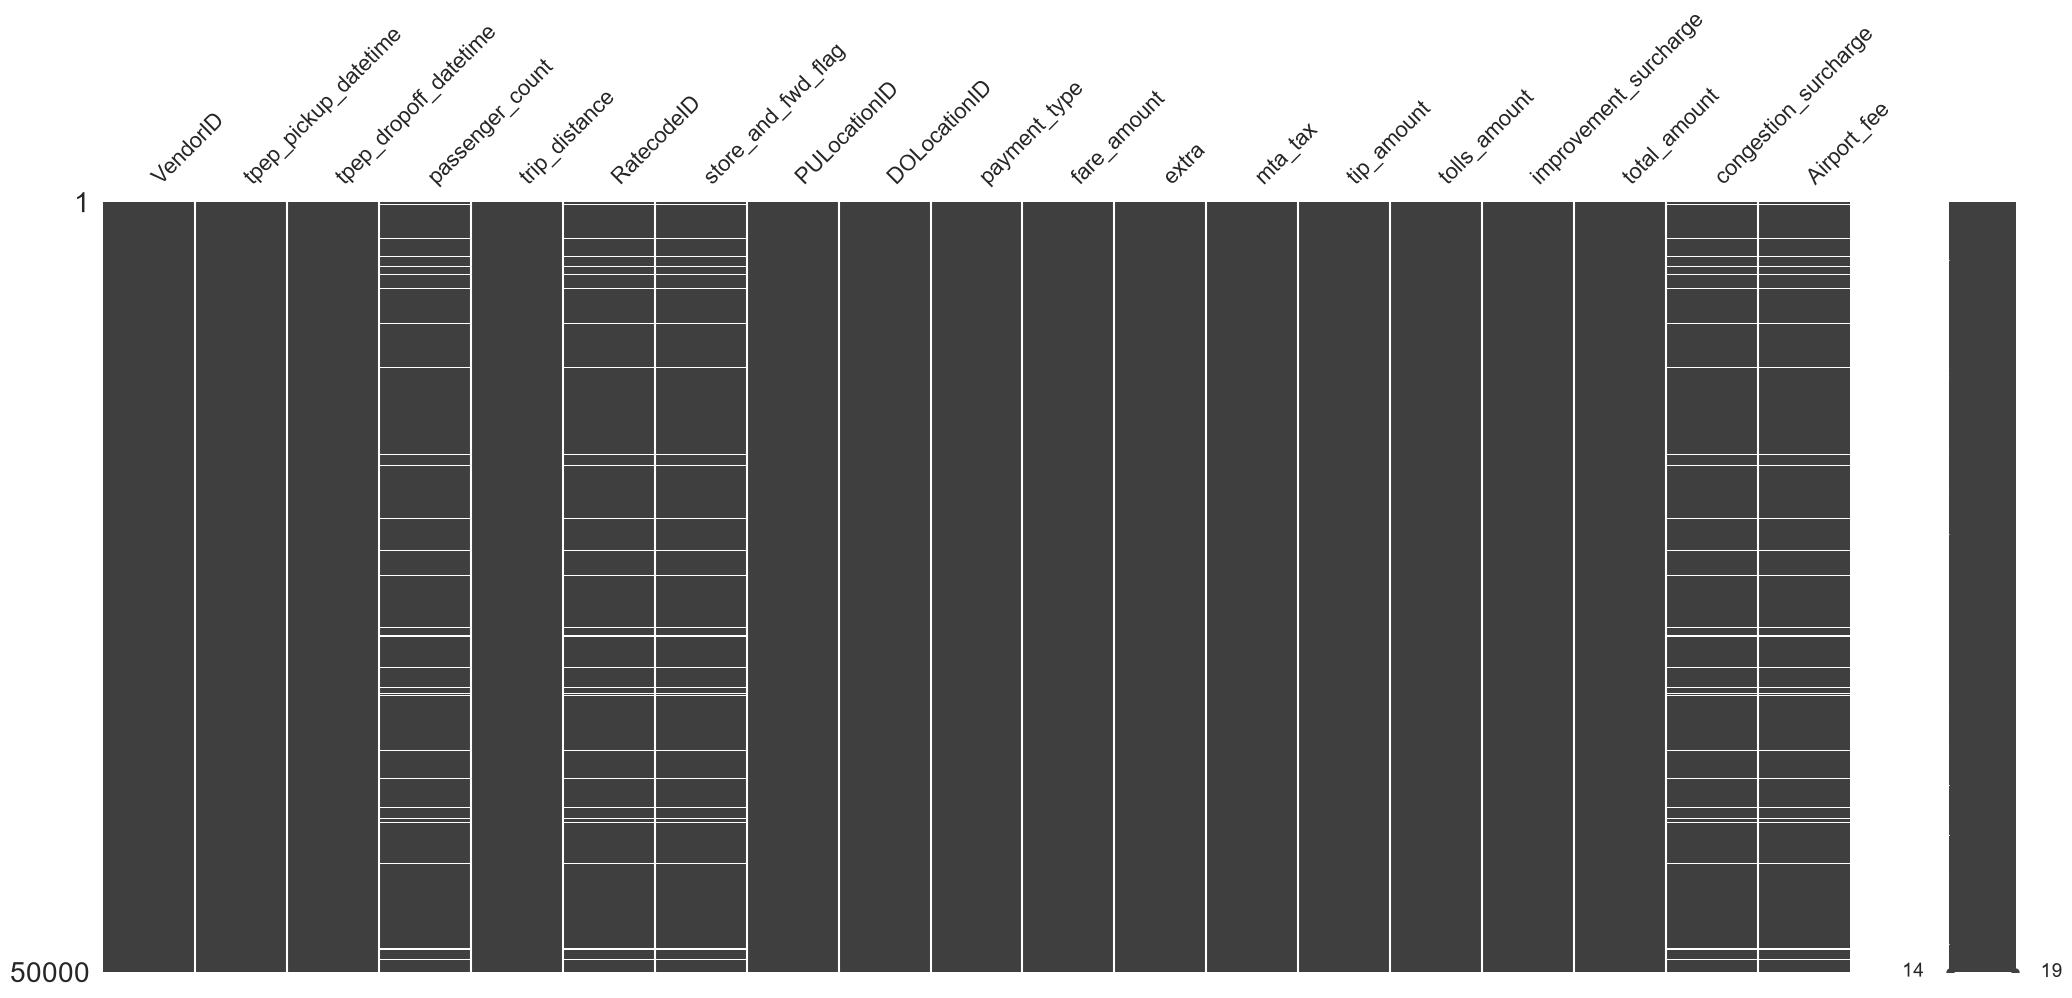

In [5]:
msno.matrix(trips.sample(50_000, random_state=0)); plt.show()

Decision: `passenger_count`, `RatecodeID`, `congestion_surcharge`, `Airport_fee` missing together (likely same source: pre-trip data enrichment gap) — flag as feature (`is_enriched`) rather than drop rows, keep for now.

## 3. Duplicates

In [6]:
print("full-row dup:", trips.duplicated().sum())

full-row dup: 0


## 4. Univariate Analysis

In [7]:
trips[["trip_distance", "fare_amount", "total_amount", "tip_amount", "passenger_count"]].describe()

,trip_distance,fare_amount,total_amount,tip_amount,passenger_count
count,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06
mean,3.652169e+00,1.817506e+01,2.680150e+01,3.335870e+00,1.339281e+00
std,2.254626e+02,1.894955e+01,2.338558e+01,3.896551e+00,8.502817e-01
min,0.000000e+00,-8.990000e+02,-9.000000e+02,-8.000000e+01,0.000000e+00
25%,1.000000e+00,8.600000e+00,1.538000e+01,1.000000e+00,1.000000e+00
50%,1.680000e+00,1.280000e+01,2.010000e+01,2.700000e+00,1.000000e+00
75%,3.110000e+00,2.050000e+01,2.856000e+01,4.120000e+00,1.000000e+00
max,3.127223e+05,5.000000e+03,5.000000e+03,4.280000e+02,9.000000e+00


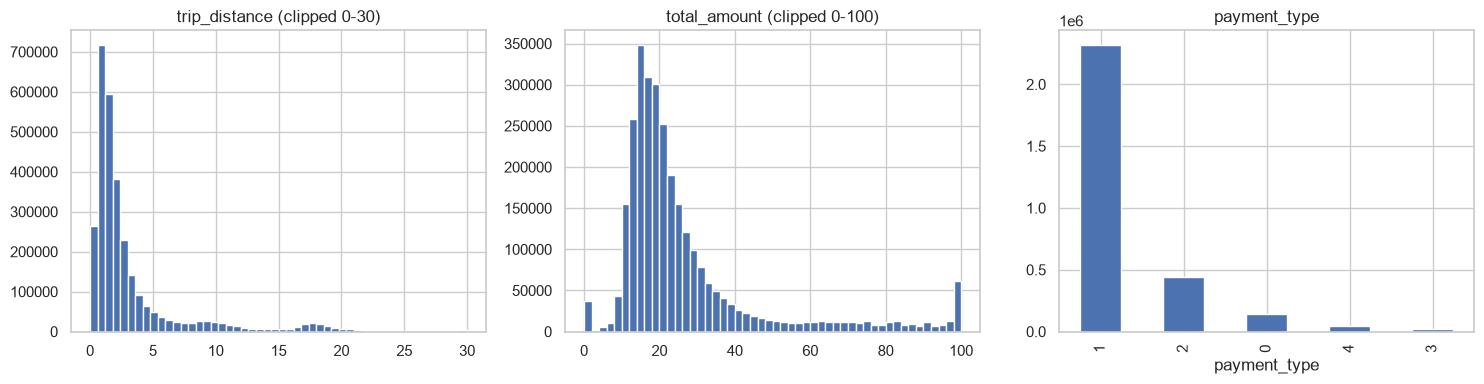

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
trips["trip_distance"].clip(0, 30).hist(bins=50, ax=ax[0]); ax[0].set_title("trip_distance (clipped 0-30)")
trips["total_amount"].clip(0, 100).hist(bins=50, ax=ax[1]); ax[1].set_title("total_amount (clipped 0-100)")
trips["payment_type"].value_counts().plot(kind="bar", ax=ax[2]); ax[2].set_title("payment_type")
plt.tight_layout(); plt.show()

## 5. Outliers

negative fare_amount: 37448
negative total_amount: 35504
zero trip_distance: 60371
trip_distance > 100 mi: 59
passenger_count == 0: 31465


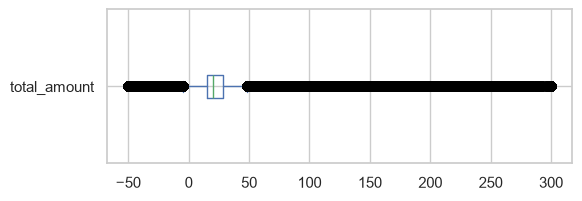

In [9]:
print("negative fare_amount:", (trips["fare_amount"] < 0).sum())
print("negative total_amount:", (trips["total_amount"] < 0).sum())
print("zero trip_distance:", (trips["trip_distance"] == 0).sum())
print("trip_distance > 100 mi:", (trips["trip_distance"] > 100).sum())
print("passenger_count == 0:", (trips["passenger_count"] == 0).sum())
trips["total_amount"].clip(-50, 300).plot(kind="box", vert=False, figsize=(6, 2)); plt.show()

Decision: negative amounts = refunds/corrections (known TLC quirk), zero-distance = flat-rate/cancelled trips — flag not drop, filter out only for distance-based modeling later.

## 6. Target Variable
N/A — no supervised task defined yet. `total_amount` (fare prediction) or `PULocationID->DOLocationID` (next-zone prediction) are candidate targets, decide later.

## 7. Bivariate / Correlation Analysis

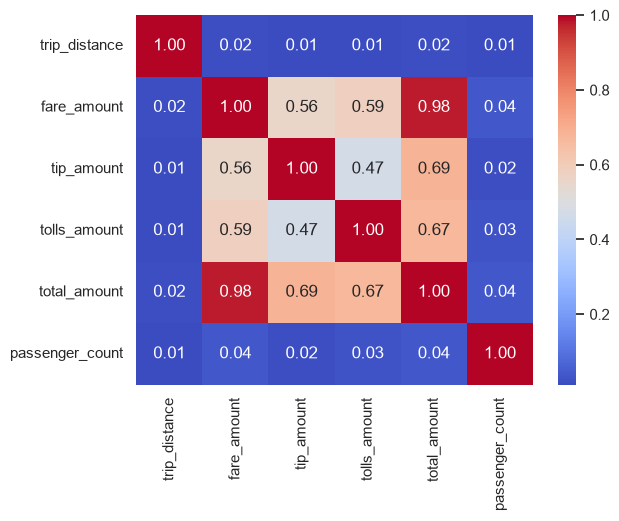

In [10]:
num_cols = ["trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount", "passenger_count"]
sns.heatmap(trips[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm"); plt.show()

## 8. Time-based Checks

In [11]:
print("pickup range:", trips["tpep_pickup_datetime"].min(), "to", trips["tpep_pickup_datetime"].max())
out_of_range = trips[(trips["tpep_pickup_datetime"] < "2024-01-01") | (trips["tpep_pickup_datetime"] >= "2024-02-01")]
print("rows outside stated month:", len(out_of_range), f"({len(out_of_range)/len(trips):.2%})")

pickup range: 2002-12-31 22:59:39 to 2024-02-01 00:01:15
rows outside stated month: 18 (0.00%)


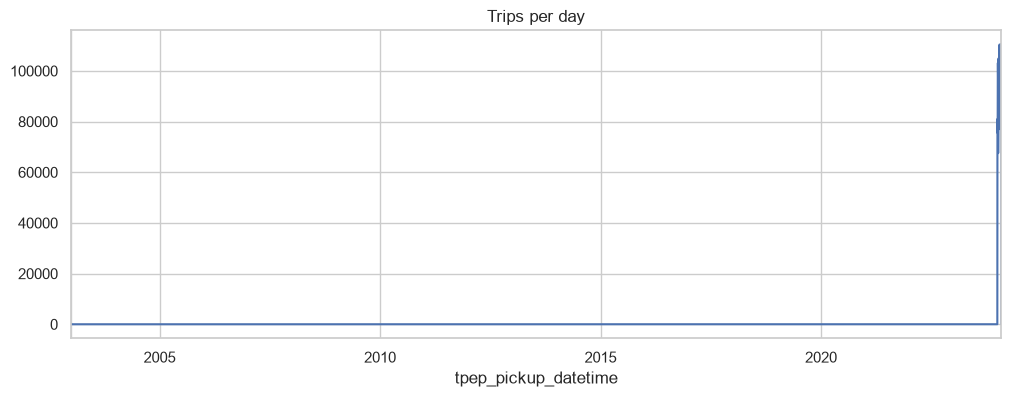

In [12]:
trips.set_index("tpep_pickup_datetime").resample("D").size().plot(figsize=(12, 4), title="Trips per day")
plt.show()

Decision: rows outside Jan-2024 are known TLC data-entry errors (documented issue) — filter out before analysis using date range.

## 9. Data Consistency

In [13]:
print("dropoff before pickup:", (trips["tpep_dropoff_datetime"] < trips["tpep_pickup_datetime"]).sum())
print("unique VendorID:", sorted(trips["VendorID"].unique()))
print("unique payment_type:", sorted(trips["payment_type"].unique()))
print("unique RatecodeID:", sorted(trips["RatecodeID"].dropna().unique()))

dropoff before pickup: 56
unique VendorID: [np.int32(1), np.int32(2), np.int32(6)]
unique payment_type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
unique RatecodeID: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(99.0)]


## 10. Feature Relationships for Recommendation Context
Reframed: pickup-zone -> dropoff-zone as implicit "interaction" (no rider ID available).

In [14]:
n_zones_pu = trips["PULocationID"].nunique()
n_zones_do = trips["DOLocationID"].nunique()
n_pairs = trips.groupby(["PULocationID", "DOLocationID"]).size().shape[0]
max_pairs = n_zones_pu * n_zones_do
print(f"pickup zones={n_zones_pu} dropoff zones={n_zones_do} observed pairs={n_pairs} sparsity={1 - n_pairs/max_pairs:.4%}")

pickup zones=260 dropoff zones=261 observed pairs=26335 sparsity=61.1922%


pickup zones with <=5 trips: 21 (8.1%)


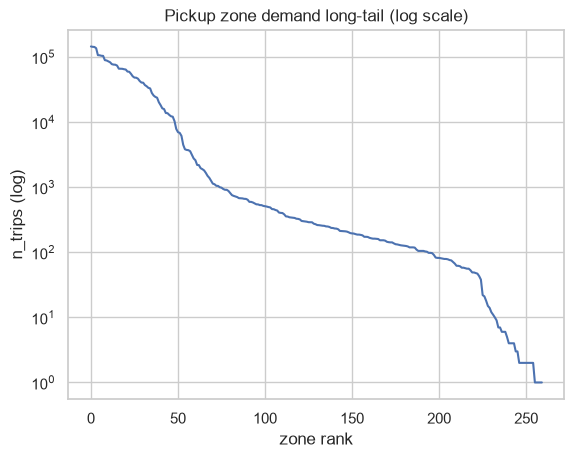

In [15]:
zone_counts = trips.groupby("PULocationID").size().sort_values(ascending=False)
cold_zones = (zone_counts <= 5).sum()
print("pickup zones with <=5 trips:", cold_zones, f"({cold_zones/n_zones_pu:.1%})")
zone_counts.reset_index(drop=True).plot(logy=True, title="Pickup zone demand long-tail (log scale)")
plt.xlabel("zone rank"); plt.ylabel("n_trips (log)"); plt.show()

## 11. Summary

- Shape: 2.96M trips, 19 columns, single month (Jan 2024).
- Missing: `passenger_count`, `RatecodeID`, `congestion_surcharge`, `Airport_fee` share same gap pattern — enrichment-stage nulls, not random.
- No full-row duplicates.
- Known TLC data quality issues confirmed present: negative fares (refunds/corrections), zero-distance trips, small fraction of pickups outside stated month — all documented quirks, need filtering before modeling not deletion of whole file.
- No rider/driver ID in this dataset — user-item framing from checklist #10 doesn't apply directly; reframed as pickup-zone -> dropoff-zone demand matrix, still very sparse and long-tail (few zones dominate volume).
- fare_amount/total_amount/tip_amount strongly correlated as expected (all fare-derived).
- No explicit supervised target yet — fare prediction or next-zone prediction are candidates.
- For next-best-product framing, this dataset useful mainly as zone-level demand signal, not classic user-item CF — keep in mind when reusing checklist #10 pattern elsewhere.